# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Muhammad Azka Ananta Khairon | 5054251004 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [30]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

In [4]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.

data = pd.read_csv('/content/data.csv')
print("Ukuran dataset:", data.shape)
data.head()

Ukuran dataset: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
data = data.drop(columns=['id', 'Unnamed: 32'])

In [7]:
print("Baris duplikat :",(data.duplicated().sum()))
print("Jumlah baris kosong:")
data.isna().sum()[data.isna().sum()>0]

Baris duplikat : 0
Jumlah baris kosong:


,0


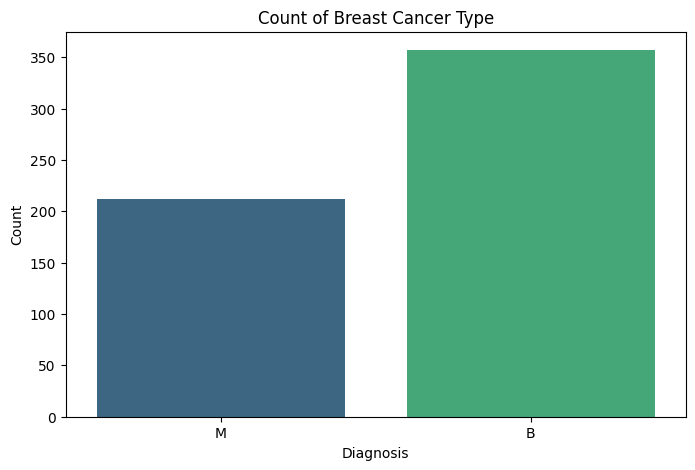

In [8]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

plt.figure(figsize=(8, 5))
sns.countplot(x='diagnosis', hue='diagnosis', data=data, palette='viridis', legend=False)
plt.title('Count of Breast Cancer Type')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

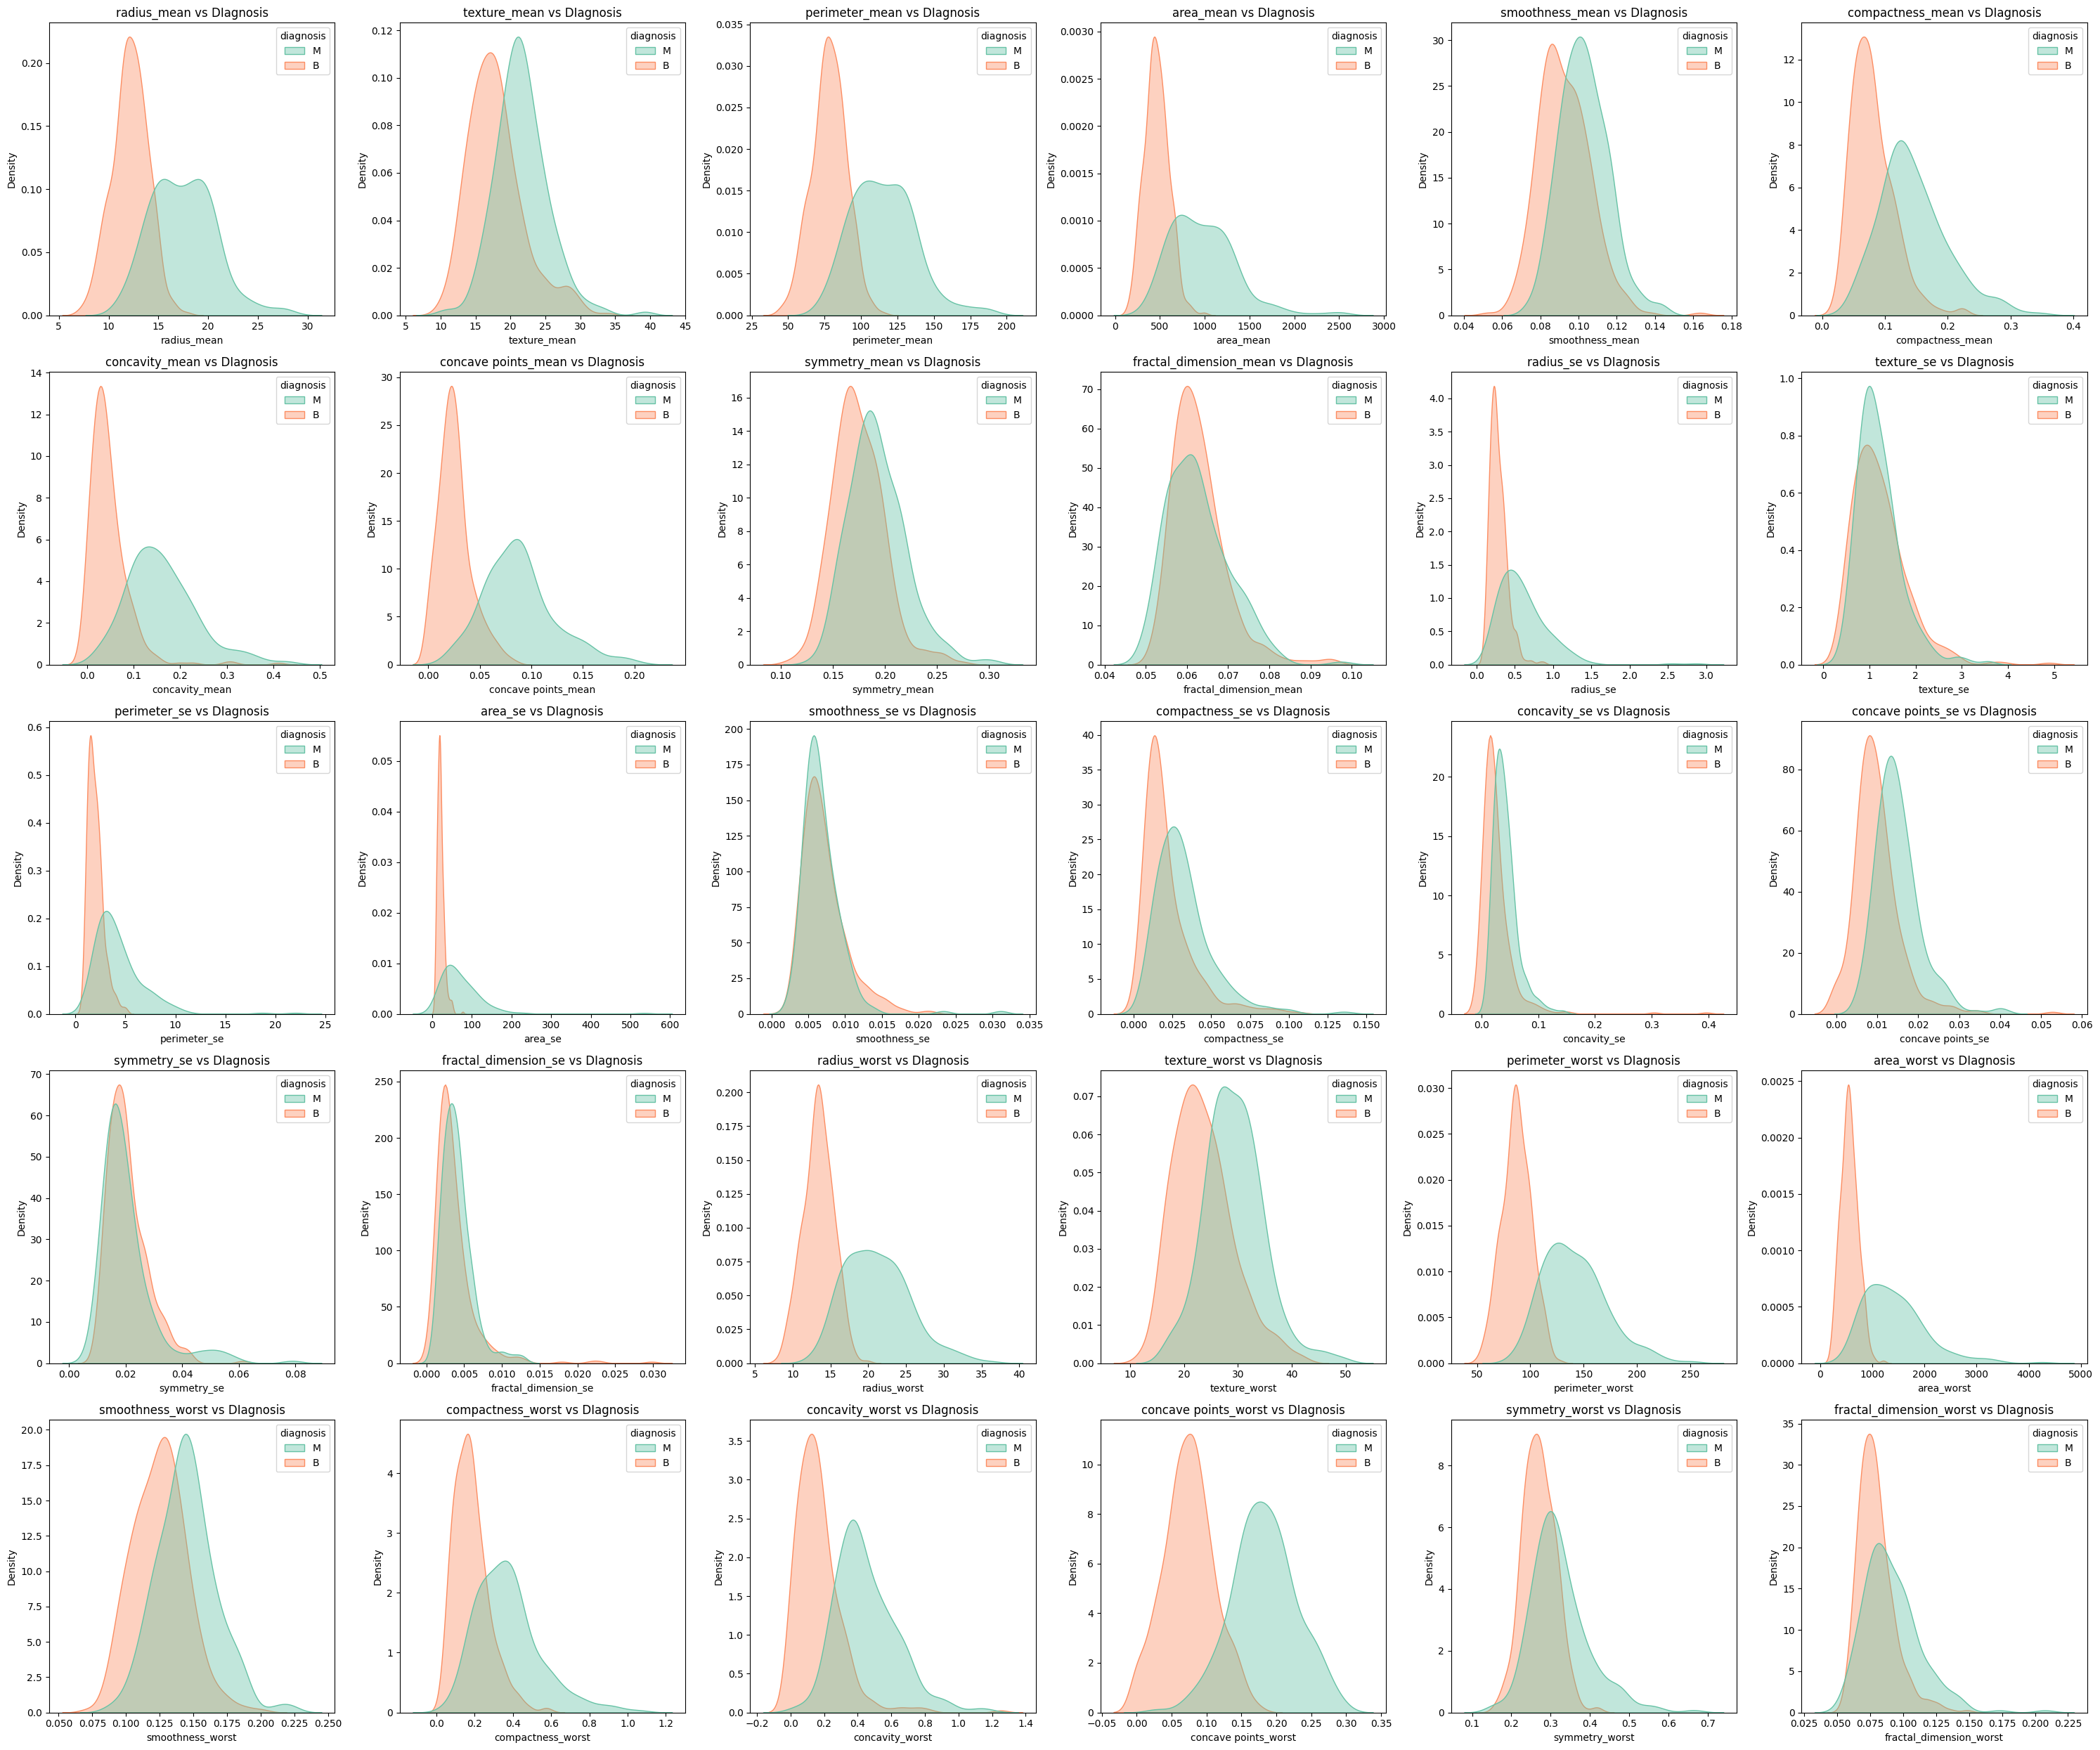

In [9]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.

kolom_fitur = [col for col in data.columns if col not in ['diagnosis']]

plt.figure(figsize=(30, 25))
for i, col in enumerate(kolom_fitur):
  plt.subplot(5, 6, i + 1)
  sns.kdeplot(data=data, x=col, hue="diagnosis", palette="Set2", fill=True, common_norm=False, alpha=0.4)
  plt.title(f"{col} vs DIagnosis")
plt.tight_layout()
plt.show()

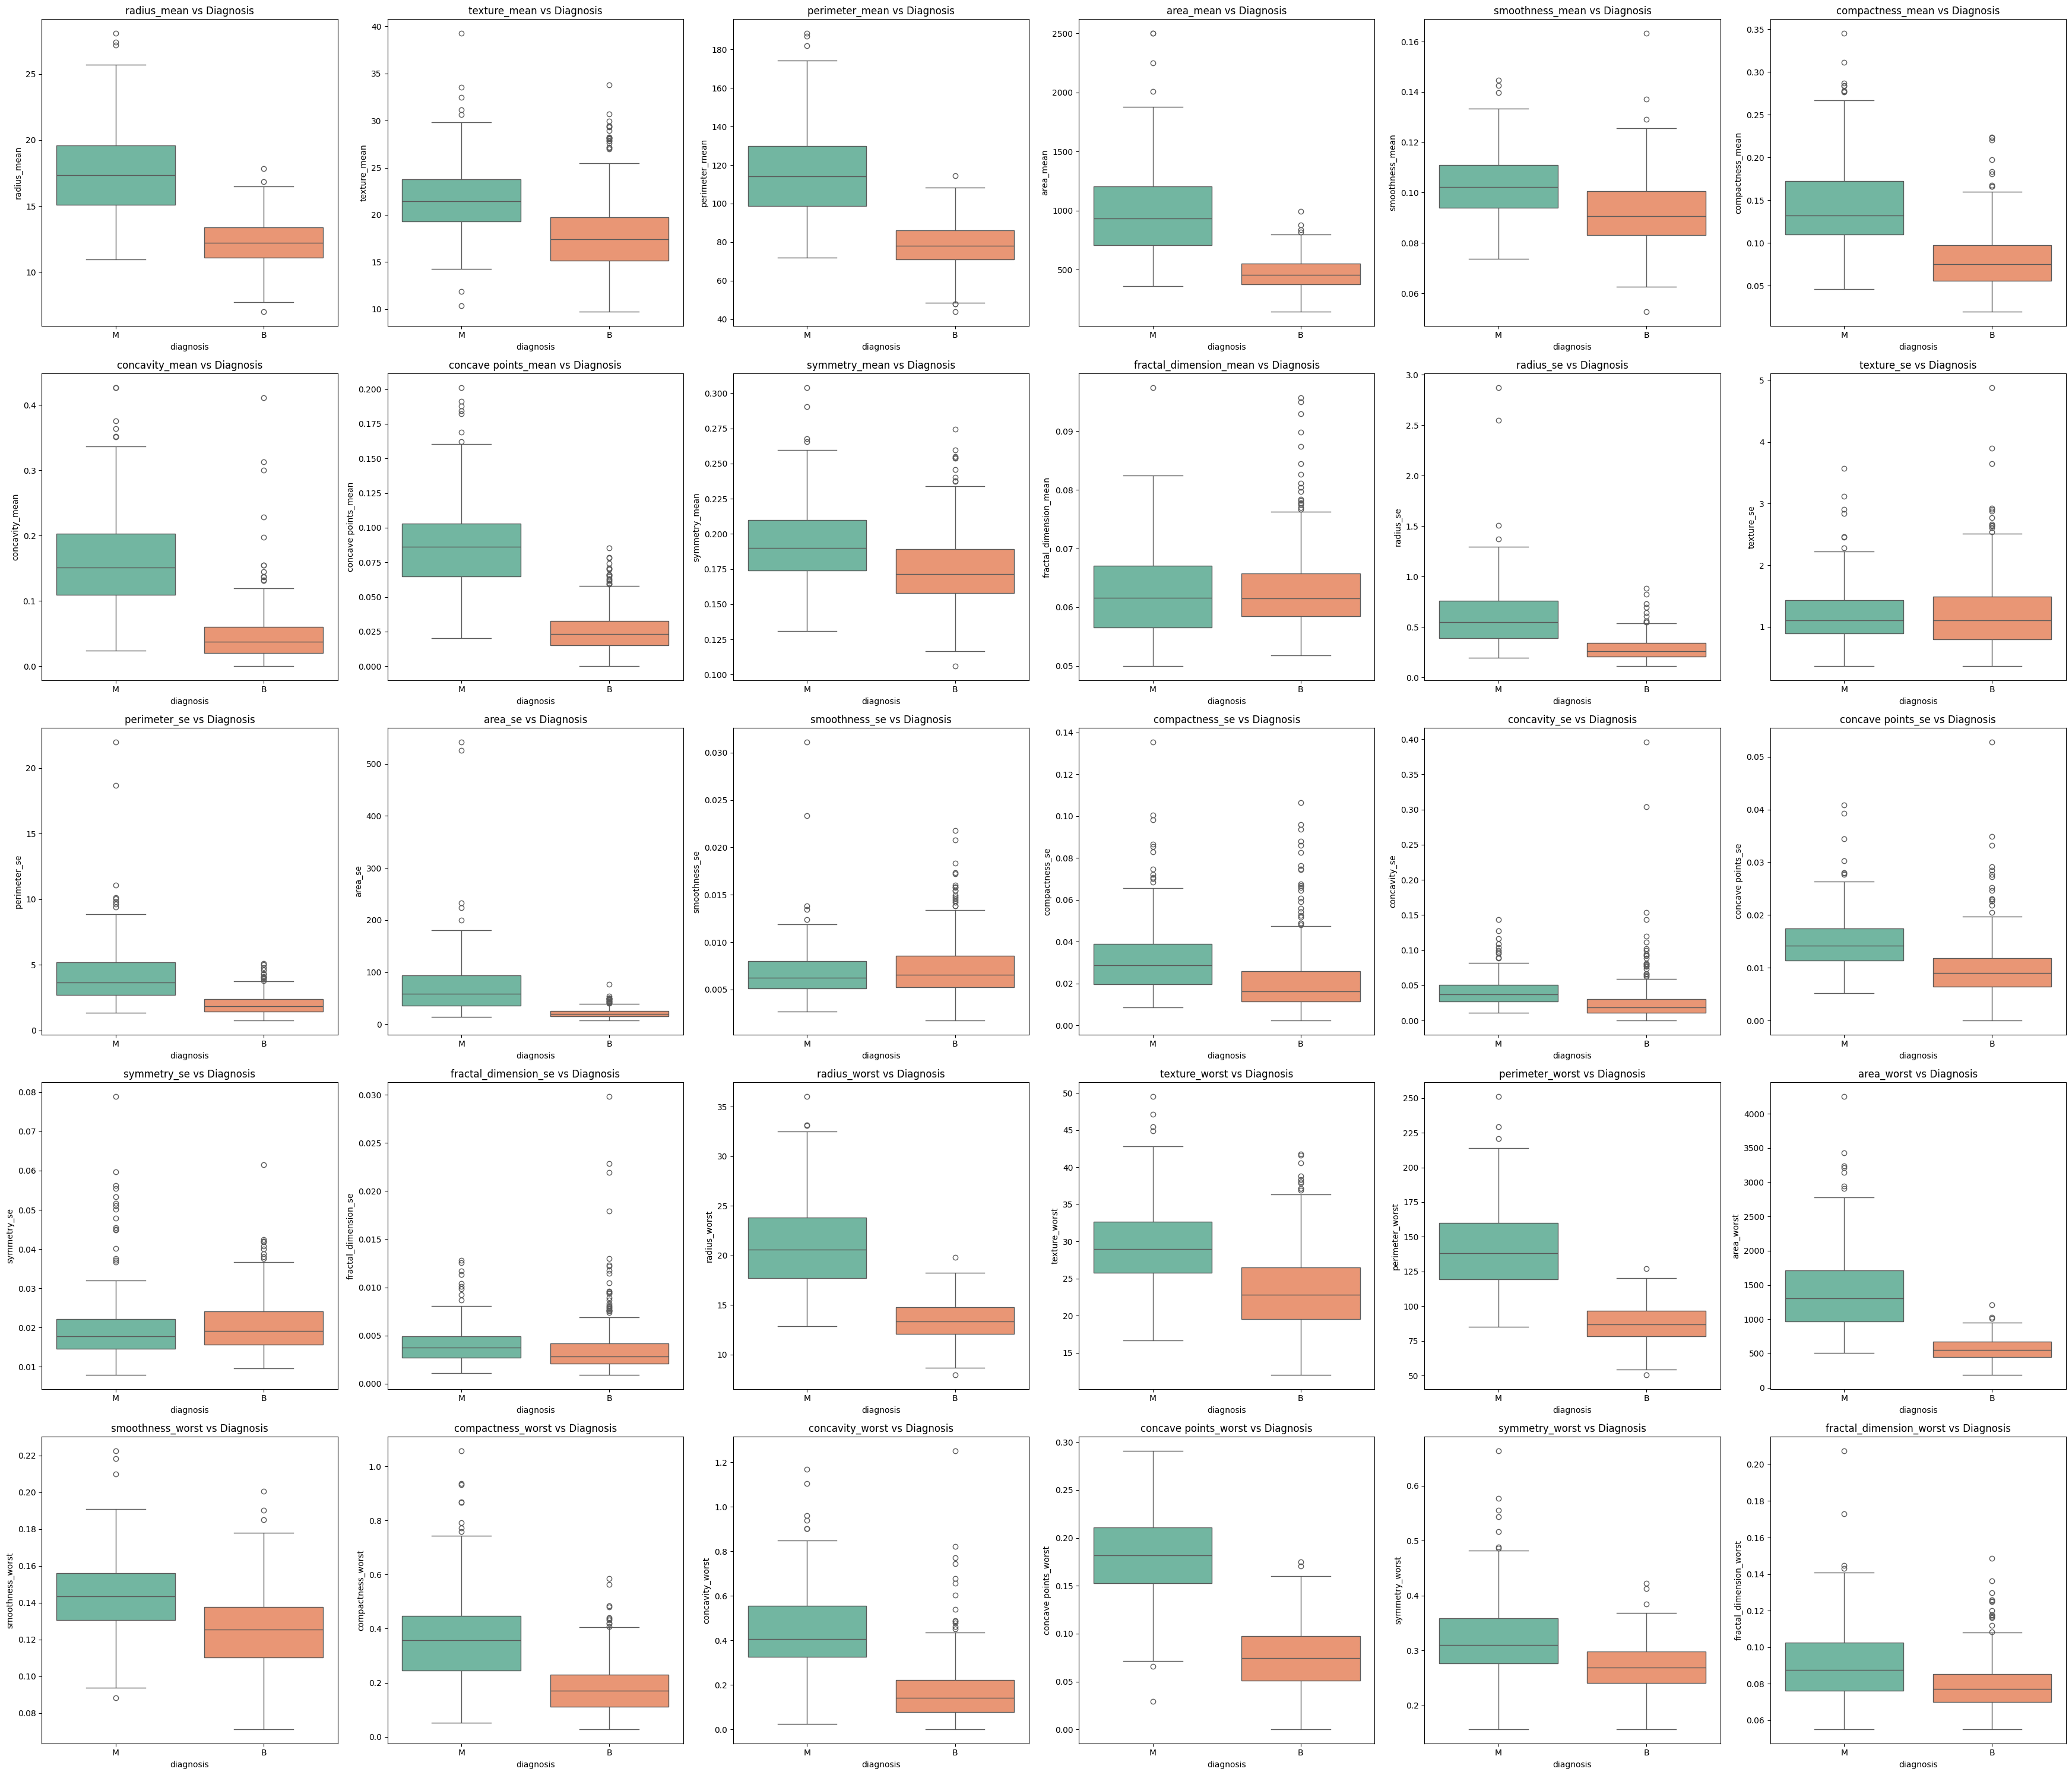

In [10]:
plt.figure(figsize=(35, 30))
for i, col in enumerate(kolom_fitur):
  plt.subplot(5, 6, i + 1)
  sns.boxplot(data=data, x="diagnosis", y=col, hue="diagnosis", palette="Set2", legend=False)
  plt.title(f"{col} vs Diagnosis")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2228/1523339519.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['diagnosis'] = data['diagnosis'].replace({'M': 0, 'B': 1}).astype(int)


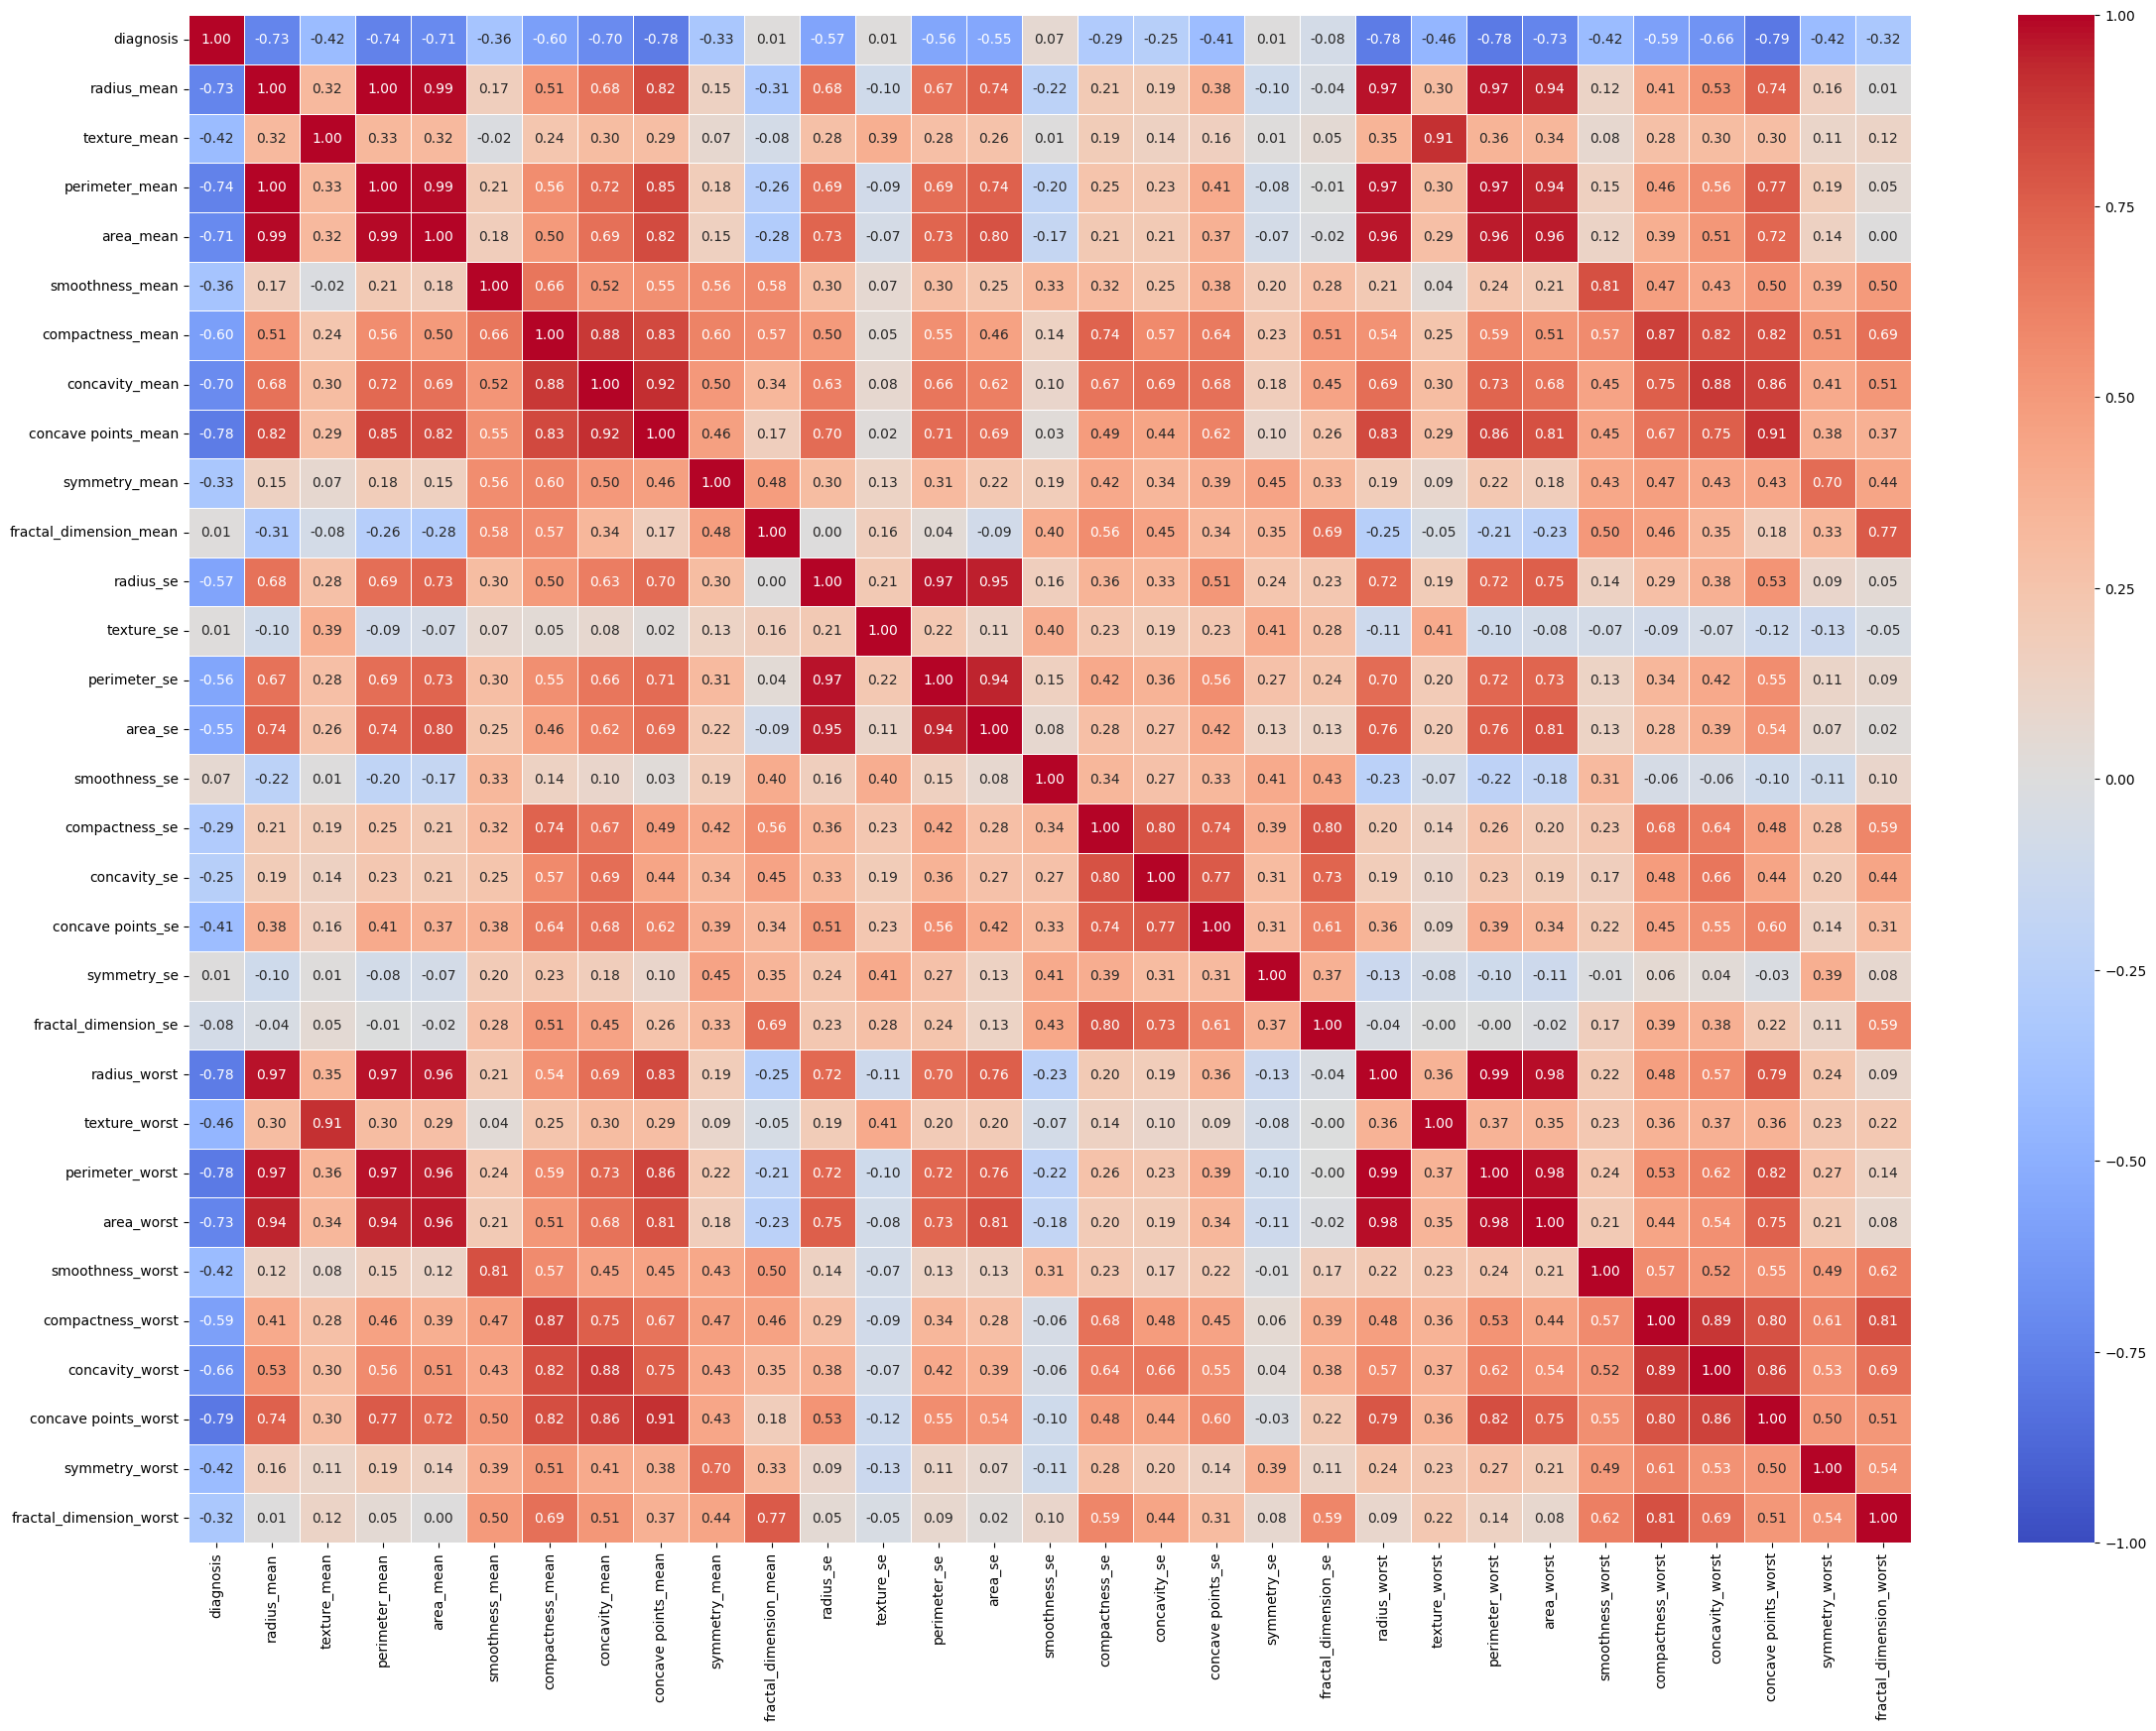

In [11]:
data['diagnosis'] = data['diagnosis'].replace({'M': 0, 'B': 1}).astype(int)

plt.figure(figsize=(28, 20))
sns.heatmap(data.corr(), cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, annot=True, fmt=".2f")
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [12]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

In [13]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).

In [14]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = data.drop(columns=["diagnosis"])
y = data["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [15]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [16]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

SVC(kernel='linear', random_state=42)

In [17]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred = svm_model.predict(X_test_scaled)

## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [18]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.

svm_rbf_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_rbf_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [19]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_rbf = svm_rbf_model.predict(X_test_scaled)

## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [27]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.

c_values = [0.01, 0.1, 1, 10, 100]

train_accuracies = []
test_accuracies = []

for C in c_values:
    model = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)

    acc_train = accuracy_score(y_train, model.predict(X_train_scaled))
    acc_test = accuracy_score(y_test, model.predict(X_test_scaled))

    train_accuracies.append(acc_train)
    test_accuracies.append(acc_test)

    print(f"C = {C:<6} | Train Accuracy: {acc_train:.4f} | Test Accuracy: {acc_test:.4f}")

C = 0.01   | Train Accuracy: 0.6264 | Test Accuracy: 0.6316
C = 0.1    | Train Accuracy: 0.9582 | Test Accuracy: 0.9474
C = 1      | Train Accuracy: 0.9824 | Test Accuracy: 0.9825
C = 10     | Train Accuracy: 0.9934 | Test Accuracy: 0.9737
C = 100    | Train Accuracy: 1.0000 | Test Accuracy: 0.9474


In [28]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

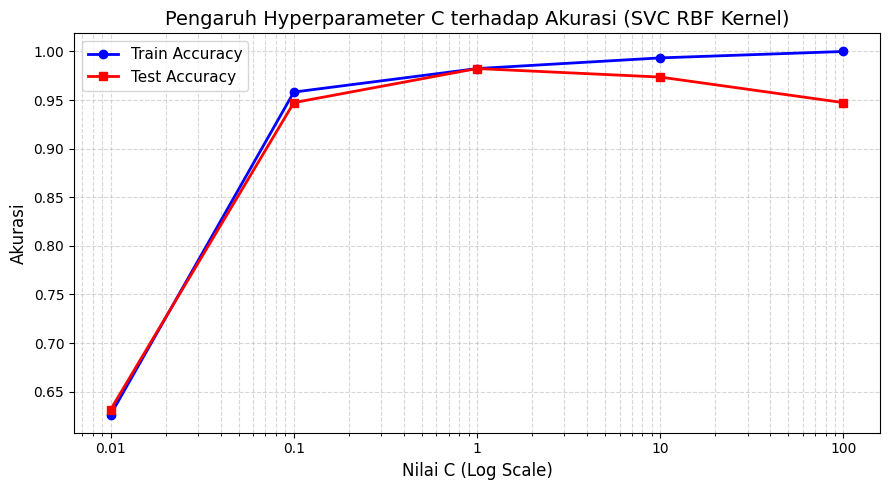

In [29]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

plt.figure(figsize=(9, 5))
plt.plot(c_values, train_accuracies, marker='o', label='Train Accuracy', color='blue', linewidth=2)
plt.plot(c_values, test_accuracies, marker='s', label='Test Accuracy', color='red', linewidth=2)

plt.xscale('log')
plt.xlabel('Nilai C (Log Scale)', fontsize=12)
plt.ylabel('Akurasi', fontsize=12)
plt.title('Pengaruh Hyperparameter C terhadap Akurasi (SVC RBF Kernel)', fontsize=14)
plt.xticks(c_values, labels=[str(c) for c in c_values])
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [32]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

metrics = {
    'Model': ['SVM Linear', 'SVM RBF'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rbf)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rbf)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rbf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rbf)
    ]
}

df_metrics = pd.DataFrame(metrics)
print("=== TABEL PERBANDINGAN METRIK EVALUASI ===")
display(df_metrics)

=== TABEL PERBANDINGAN METRIK EVALUASI ===


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM Linear,0.973684,0.985915,0.972222,0.979021
1,SVM RBF,0.982456,0.986111,0.986111,0.986111


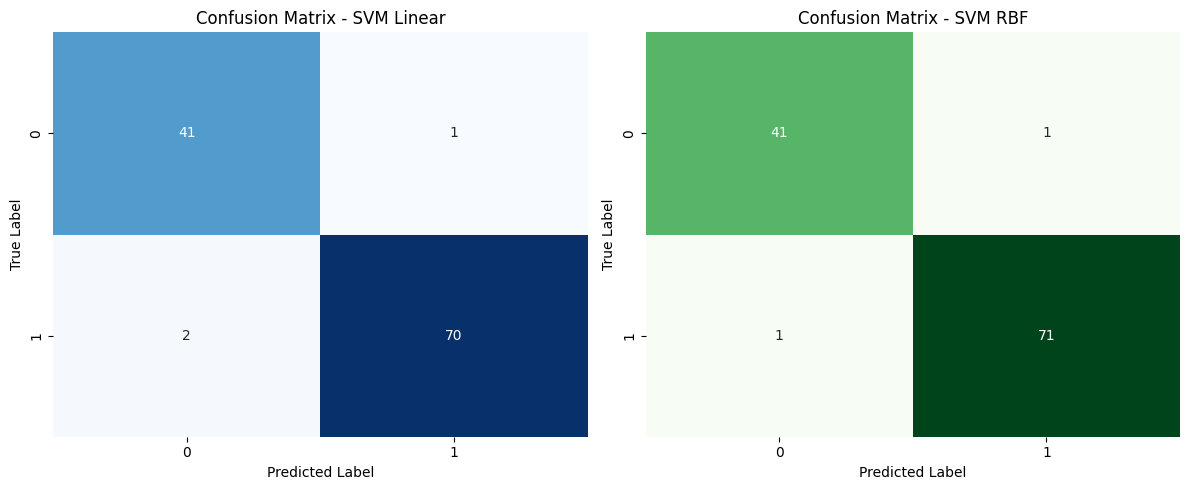

In [33]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

cm_linear = confusion_matrix(y_test, y_pred)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix - SVM Linear', fontsize=12)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix - SVM RBF', fontsize=12)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [34]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.

print("\n=== ANALISIS SUPPORT VECTORS ===")
print(f"Jumlah Support Vectors (Kernel Linear) : {svm_model.n_support_.sum()} "
      f"(Malignant: {svm_model.n_support_[0]}, Benign: {svm_model.n_support_[1]})")
print(f"Jumlah Support Vectors (Kernel RBF)    : {svm_rbf_model.n_support_.sum()} "
      f"(Malignant: {svm_rbf_model.n_support_[0]}, Benign: {svm_rbf_model.n_support_[1]})")


=== ANALISIS SUPPORT VECTORS ===
Jumlah Support Vectors (Kernel Linear) : 32 (Malignant: 15, Benign: 17)
Jumlah Support Vectors (Kernel RBF)    : 97 (Malignant: 51, Benign: 46)


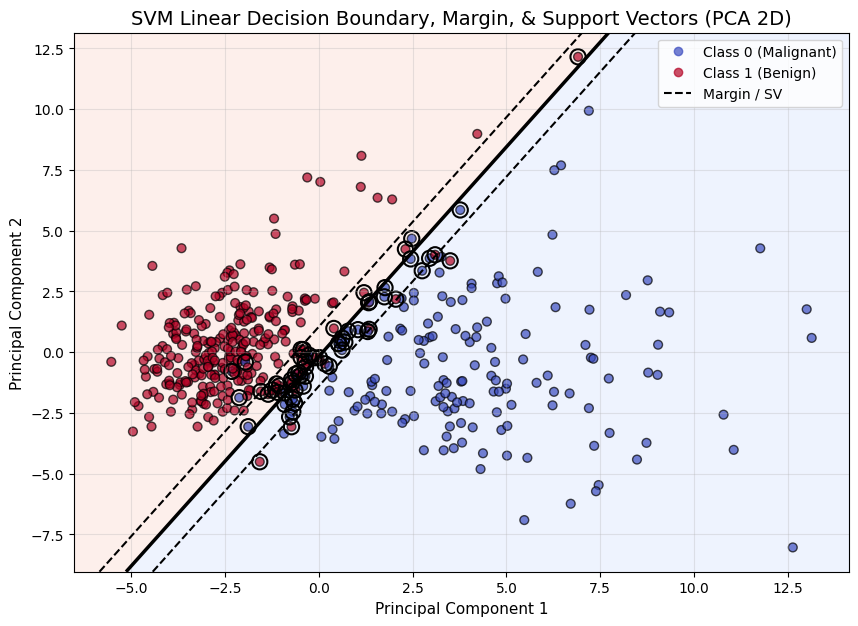

In [35]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model_pca = SVC(kernel='linear', C=1.0, random_state=42)
model_pca.fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model_pca.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z > 0, alpha=0.15, cmap='coolwarm')

plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'], linewidths=[1.5, 2.5, 1.5])

scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', alpha=0.7, s=40)

sv = model_pca.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none', edgecolors='black', linewidths=1.5, label='Support Vectors')

plt.title('SVM Linear Decision Boundary, Margin, & Support Vectors (PCA 2D)', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=11)
plt.ylabel('Principal Component 2', fontsize=11)
plt.legend(handles=scatter.legend_elements()[0] + [plt.Line2D([0], [0], color='black', linestyle='--')],
           labels=['Class 0 (Malignant)', 'Class 1 (Benign)', 'Margin / SV'])
plt.grid(True, alpha=0.3)
plt.show()

# 5. Analisis

# Pembahasan dan Analisis Hasil Eksperimen SVM

## 1. Perbandingan Performa SVM Kernel Linear vs RBF

Berdasarkan metrik evaluasi pada uji coba, model **SVM Kernel RBF** mencatatkan performa yang sedikit lebih unggul dibandingkan **SVM Kernel Linear**:

| Model | Accuracy | Precision | Recall | F1-Score |
| :--- | :---: | :---: | :---: | :---: |
| **SVM Linear** | 0.973684 | 0.985915 | 0.972222 | 0.979021 |
| **SVM RBF** | **0.982456** | **0.986111** | **0.986111** | **0.986111** |

### Signifikansi Perbedaan Performa
Perbedaan performa antara kedua kernel ini **tidak terlalu signifikan** (selisih akurasi hanya sekitar 0.88%). Kedua model sama-sama mampu memisahkan kelas *Malignant* dan *Benign* dengan sangat baik, dengan nilai presisi dan sensitivitas di atas 97%.

### Hubungan dengan Sebaran Data pada EDA
Hasil ini sejalan dengan karakteristik *Breast Cancer Wisconsin Dataset*. Pada tahap EDA, sebagian besar fitur numerik (seperti `radius_mean`, `perimeter_mean`, `area_mean`, dan `concavity_mean`) menunjukkan pemisahan (*separability*) antar dua kelas yang sudah cukup jelas secara linier di ruang fitur berdimensi tinggi.

* Karena datanya secara alami sudah hampir terpisah secara linier (*linearly separable*), kernel **Linear** mampu membentuk *hyperplane* lurus yang sangat akurat.
* Kernel **RBF** mampu memetakan data ke ruang laten yang sedikit lebih fleksibel untuk menangkap beberapa titik data yang saling tumpang-tindih (*overlapping*) di sekitar batas keputusan, sehingga memberikan peningkatan tipis pada Recall dan F1-Score.

---

## 2. Temuan Eksperimen Regularisasi (Nilai $C$) dan Gejala Overfitting

Eksperimen variasi nilai $C$ ($0.01, 0.1, 1, 10, 100$) pada kernel RBF menunjukkan dinamika *bias-variance tradeoff*:

* **Underfitting ($C = 0.01$):**
  Akurasi *training* dan *testing* berada di tingkat paling rendah ($\approx 63\%$)[cite: 2]. Nilai $C$ yang terlalu kecil memberikan toleransi kesalahan (*soft margin*) yang terlalu longgar, sehingga model terlalu sederhana dan gagal mempelajari pola data.
* **Kondisi Optimal ($C = 1$):**
  Model mencapai titik keseimbangan (*generalization sweet spot*) terbaik. Akurasi *training* dan *testing* sama-sama mencapai puncaknya di angka **98.25%**[cite: 2].
* **Indikasi Overfitting ($C = 10$ hingga $C = 100$):**
  Model mulai menunjukkan gejala **overfitting** saat nilai $C$ dinaikkan ke $10$ dan terlihat semakin jelas pada $C = 100$.

### Ciri-Ciri Overfitting pada Grafik
1. **Divergensik Kurva:** Terjadi pemisahan kurva yang makin lebar antara *Train Accuracy* dan *Test Accuracy*.
2. **Perbedaan Tren Akurasi:** Saat nilai $C$ dinaikkan dari $1$ ke $100$, kurva *Train Accuracy* (garis biru) terus naik hingga menyentuh **100%** (1.00)[cite: 2]. Namun, kurva *Test Accuracy* (garis merah) justru mengalami penurunan dari **98.25%** menjadi **94.74%**.
3. **Penyebab:** Nilai $C$ yang besar mengharuskan penalti margin yang sangat keras (*hard margin*), memaksa model untuk mengklasifikasikan seluruh titik data *training* secara sempurna, sehingga model mulai "menghafal" *noise* dan *outlier* pada *train set*.

---

## 3. Perbandingan Jumlah Support Vectors (Linear vs RBF)

Hasil ekstraksi *support vectors* dari kedua model menunjukkan perbedaan kuantitas yang signifikan:

* **Kernel Linear:** Membutuhkan total **32 support vectors** (15 Malignant, 17 Benign).
* **Kernel RBF:** Membutuhkan total **97 support vectors** (51 Malignant, 46 Benign).

### Hubungan Jumlah Support Vectors dengan Kompleksitas Batas Keputusan
1. **Kapasitas & Kompleksitas Model:**
   Jumlah *support vectors* mencerminkan kompleksitas bentuk *decision boundary* yang terbentuk. Kernel **Linear** hanya membentuk *hyperplane* datar/lurus, sehingga ia hanya memerlukan sedikit titik sampel di sekitar margin ($\approx 32$ titik) untuk menopang garis pembatas tersebut.
2. **Karakteristik Kernel RBF:**
   Kernel **RBF** bekerja menggunakan fungsi basis radial (jarak Gaussian). Untuk membentuk batas keputusan non-linear yang melengkung dan fleksibel mengelilingi klaster data, RBF memerlukan lebih banyak titik referensi ($\approx 97$ titik) sebagai pusat-pusat kurvatur.
3. **Efisiensi Memori & Generalisasi:**
   Meskipun RBF sedikit lebih unggul dalam akurasi, model Linear jauh lebih efisien dari segi memori dan waktu inferensi karena jumlah *support vectors*-nya yang jauh lebih sedikit. Ini membuktikan bahwa untuk dataset Wisconsin Breast Cancer, model **Linear** menawarkan alternatif yang sangat kuat, simpel, dan tidak rentan *overfitting*.

# 6. Kesimpulan dan Saran

## Kesimpulan & Saran

### Kesimpulan
1. **Performa Kernel:** SVM dengan kernel RBF memberikan performa sedikit lebih tinggi (Akurasi 98.25%) dibandingkan kernel Linear (Akurasi 97.37%). Namun, kernel Linear sudah sangat memadai karena fitur pada dataset ini memiliki pemisahan linier (*linear separability*) yang jelas.
2. **Pengaruh Hyperparameter C:** Nilai $C = 1$ merupakan titik optimal untuk kernel RBF. Nilai $C$ yang terlalu kecil ($C \le 0.1$) memicu *underfitting*, sedangkan nilai $C$ yang terlalu besar ($C \ge 10$) memicu *overfitting* yang ditandai dengan *Train Accuracy* mencapai 100% sementara *Test Accuracy* turun ke 94.74%.
3. **Kompleksitas Model:** Kernel Linear hanya membutuhkan 32 *support vectors* untuk membentuk *decision boundary*, sedangkan RBF membutuhkan 97 *support vectors* untuk membentuk batas keputusan non-linier yang lebih fleksibel.

---

### Saran
1. **Eksperimen Kernel & Tuning:** Melakukan pencarian hiperparameter secara sistematis menggunakan `GridSearchCV` atau `RandomizedSearchCV` untuk mengoptimalkan kombinasi nilai $C$, $\gamma$ (gamma), serta menguji kernel lain seperti **Polynomial** atau **Sigmoid**.
2. **Reduksi Dimensi & Seleksi Fitur:** Menerapkan teknik seleksi fitur atau reduksi dimensi (PCA) sebelum melatih model untuk mengurangi multikolinearitas dan mempercepat waktu komputasi.